<a href="https://colab.research.google.com/github/SodisettiRakesh123/hanuman-/blob/main/Superstore_Sales_and_Profitability_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Unzip Dataset Archive
This cell uses the `!unzip` shell command to extract the contents of the `/content/archive (28).zip` file into the `/content/` directory. This makes the `Sample - Superstore.csv` file available for loading into a pandas DataFrame.

In [2]:
!unzip "/content/archive (28).zip" -d "/content/"

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Archive:  /content/archive (28).zip
replace /content/Sample - Superstore.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replac

### Load Data and Initial Setup
This cell performs the initial data loading and sets up the plotting environment:
-   **Imports Libraries:** `pandas` for data manipulation, `numpy` for numerical operations, `matplotlib.pyplot` for basic plotting, and `seaborn` for enhanced visualizations.
-   **Sets Plotting Style:** Configures `matplotlib` to use the 'seaborn-v0_8' style and sets a color palette for `seaborn` plots to 'Set2'.
-   **Loads Data:** Reads the `Sample - Superstore.csv` file into a pandas DataFrame named `df`. It specifies `encoding='latin1'` to handle potential character encoding issues in the CSV file.
-   **Displays Head:** Shows the first few rows of the DataFrame (`df.head()`) to give a quick overview of the loaded data's structure and content.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")

file_path = "/content/Sample - Superstore.csv"
df = pd.read_csv(file_path, encoding='latin1')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


### Initial Data Quality Checks
This cell performs essential data quality checks to understand the dataset's structure and cleanliness:
-   **`df.shape`**: Displays the number of rows and columns in the DataFrame.
-   **`df.columns`**: Lists all column names in the DataFrame.
-   **`df.info()`**: Provides a concise summary of the DataFrame, including the data types of each column, non-null values, and memory usage.
-   **`df.describe(include="all").T`**: Generates descriptive statistics for all columns, including numerical (mean, std, min, max, quartiles) and categorical (count, unique, top, freq) data.
-   **`df.isna().sum()`**: Calculates the count of missing (NaN) values for each column.
-   **`df.duplicated().sum()`**: Counts the number of duplicate rows in the DataFrame.

In [3]:
df.shape
df.columns

df.info()
df.describe(include="all").T

df.isna().sum()
df.duplicated().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

np.int64(0)

### Data Cleaning and Preprocessing
This cell performs essential data cleaning and preprocessing steps:
-   **Drop ID-like columns:** Removes columns that are unique identifiers and unlikely to be useful for direct analysis, such as 'Row ID'.
-   **Convert Date Columns:** Transforms 'Order Date' and 'Ship Date' columns into datetime objects, enabling time-series analysis.
-   **Drop Duplicates:** Identifies and removes any duplicate rows in the DataFrame, ensuring data uniqueness.
-   **Handle Missing Values:** Drops rows containing any missing (NaN) values. This is a simple approach suitable when missing data is minimal.

In [4]:
# Drop obvious ID-like columns if you don’t need them for analysis
for col in ["Row ID"]:
    if col in df.columns:
        df = df.drop(columns=col)

# Convert dates
for col in ["Order Date", "Ship Date"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col])

# Drop duplicates
df = df.drop_duplicates().reset_index(drop=True)

# Handle missing values (simple approach)
# If few missing rows, you can drop them
df = df.dropna()
df.isna().sum()


,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0
State,0


### Feature Engineering and KPI Calculation
This cell performs feature engineering related to dates and calculates key performance indicators (KPIs):
-   **Create Date Parts:** Extracts the year, month, and month name from the 'Order Date' column to facilitate time-series analysis.
-   **Calculate KPIs:** Computes various Key Performance Indicators such as total sales, total profit, profit margin, total quantity sold, and total number of unique orders. These KPIs provide a high-level overview of the business performance.

In [5]:
# Create date parts
if "Order Date" in df.columns:
    df["Order_Year"] = df["Order Date"].dt.year
    df["Order_Month"] = df["Order Date"].dt.month
    df["Order_MonthName"] = df["Order Date"].dt.strftime("%b")

# KPIs
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_quantity = df["Quantity"].sum()
total_orders = df["Order ID"].nunique() if "Order ID" in df.columns else len(df)
profit_margin = total_profit / total_sales

kpi = {
    "Total Sales": total_sales,
    "Total Profit": total_profit,
    "Profit Margin": profit_margin,
    "Total Quantity": total_quantity,
    "Total Orders": total_orders
}
kpi


{'Total Sales': np.float64(2296919.4883000003),
 'Total Profit': np.float64(286409.0805),
 'Profit Margin': np.float64(0.12469269469779175),
 'Total Quantity': np.int64(37871),
 'Total Orders': 5009}

### Monthly Sales and Profit Trends
This cell analyzes and visualizes the monthly sales and profit trends over the years:
-   **Aggregates Data:** Groups the DataFrame by 'Order_Year', 'Order_Month', and 'Order_MonthName' to calculate the total 'Sales' and 'Profit' for each month.
-   **Sorts Data:** Sorts the aggregated data by year and month to ensure correct chronological plotting.
-   **Visualizes Sales Trend:** Uses a line plot to show the 'Sales' trend across months, with different lines representing each 'Order_Year'. This helps identify seasonal patterns and annual growth.
-   **Visualizes Profit Trend:** Uses another line plot to display the 'Profit' trend similarly, allowing for a comparison of how profitability changes over months and years.

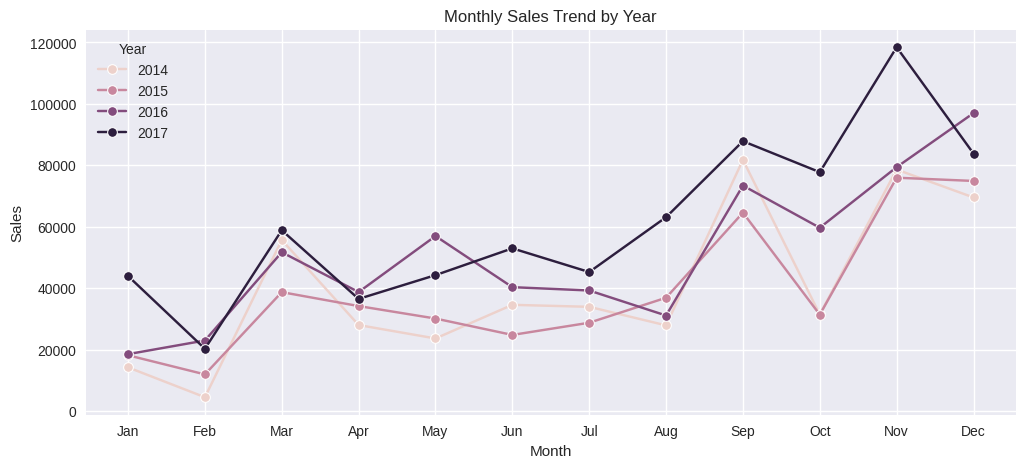

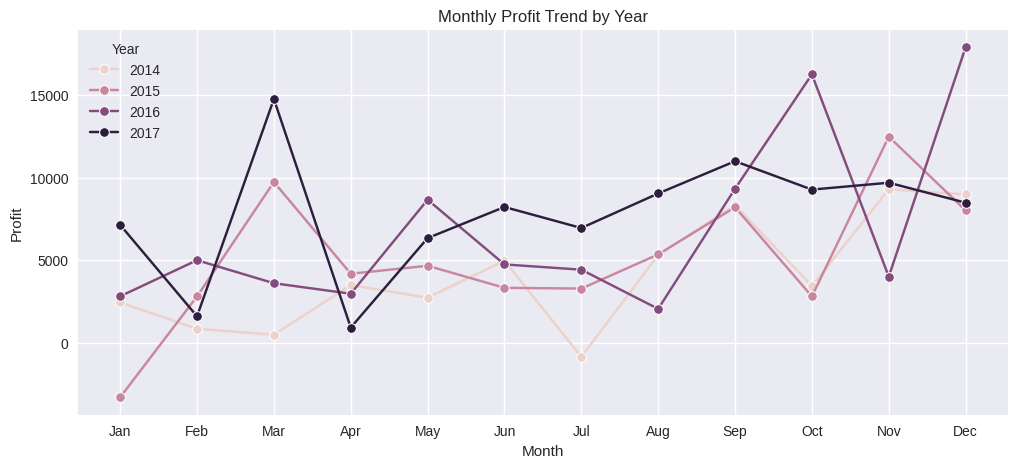

In [6]:
monthly = df.groupby(["Order_Year", "Order_Month", "Order_MonthName"], as_index=False)[["Sales", "Profit"]].sum()
monthly = monthly.sort_values(["Order_Year", "Order_Month"])

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly, x="Order_MonthName", y="Sales", hue="Order_Year", marker="o")
plt.title("Monthly Sales Trend by Year")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend(title="Year")
plt.show()

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly, x="Order_MonthName", y="Profit", hue="Order_Year", marker="o")
plt.title("Monthly Profit Trend by Year")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.legend(title="Year")
plt.show()


### Sales and Profit Analysis by Category and Sub-Category
This cell analyzes sales and profit performance across different product categories and sub-categories:
-   **Aggregates Data:** Groups the DataFrame by 'Category' and 'Sub-Category' to calculate total 'Sales' and 'Profit'.
-   **Visualizes Category Performance:** Uses a bar plot to show total 'Sales' by 'Category', providing a high-level overview of which categories contribute most to revenue.
-   **Visualizes Top Sub-Category Sales:** Displays a bar plot of the top 10 'Sub-Categories' by 'Sales', identifying specific product groups that are top sellers.
-   **Visualizes Top Sub-Category Profit:** Presents a bar plot of the top 10 'Sub-Categories' by 'Profit', highlighting which product groups are most profitable.

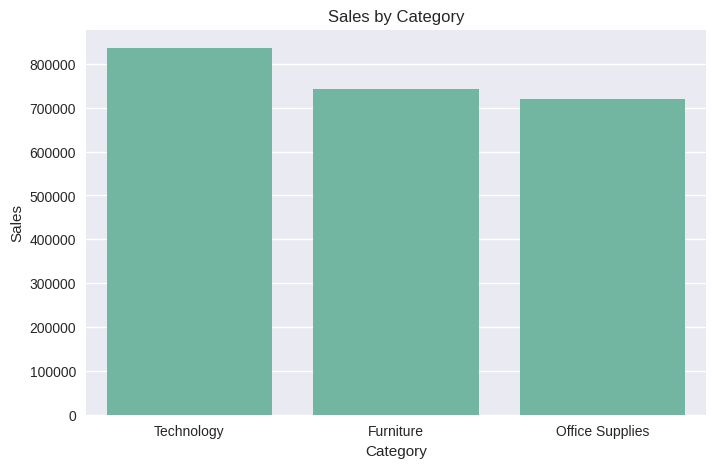

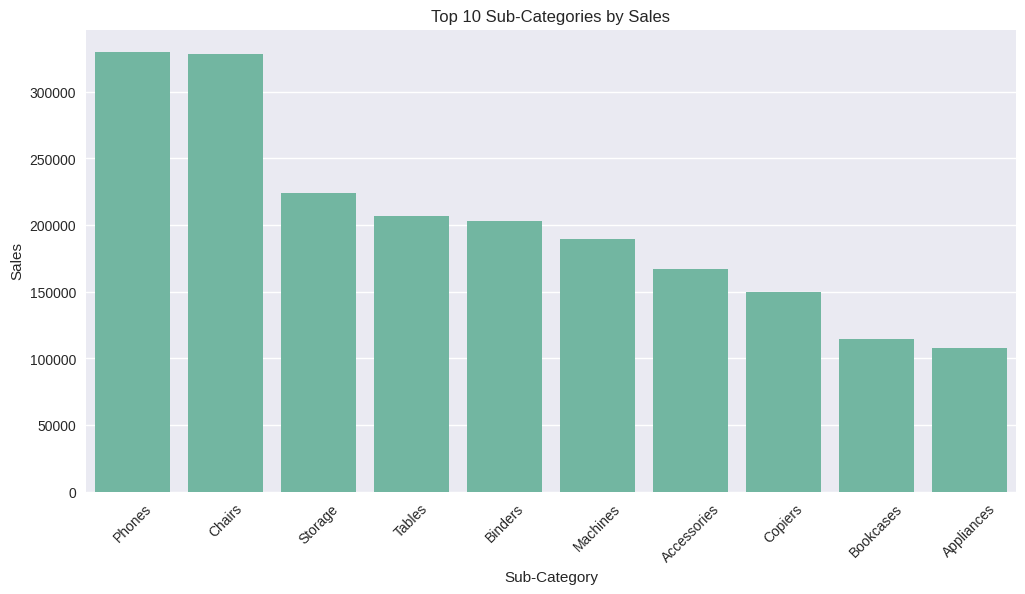

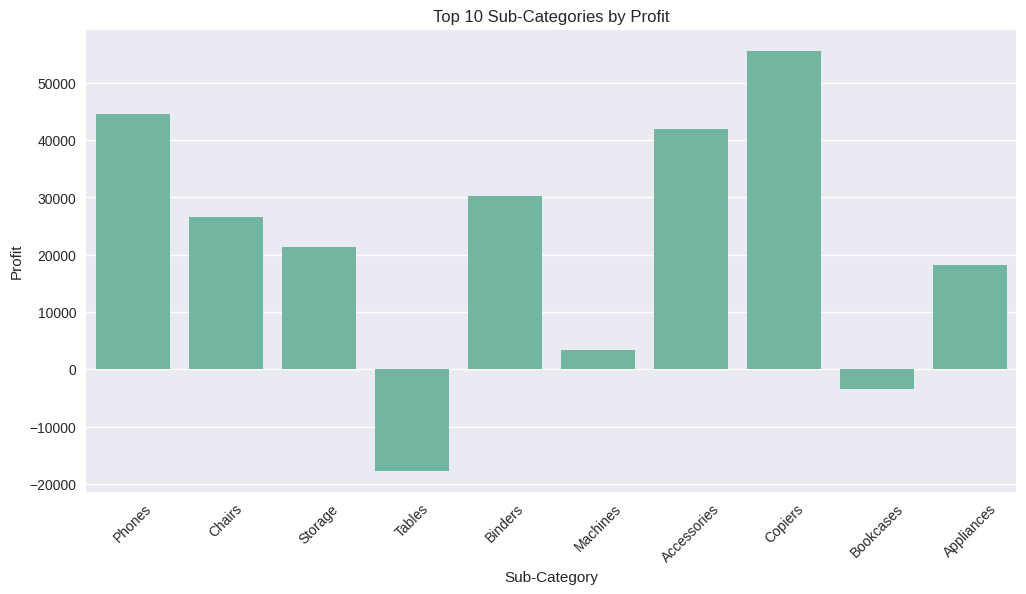

In [7]:
cat = df.groupby("Category", as_index=False)[["Sales", "Profit"]].sum().sort_values("Sales", ascending=False)
subcat = df.groupby("Sub-Category", as_index=False)[["Sales", "Profit"]].sum().sort_values("Sales", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=cat, x="Category", y="Sales")
plt.title("Sales by Category")
plt.ylabel("Sales")
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=subcat.head(10), x="Sub-Category", y="Sales")
plt.title("Top 10 Sub-Categories by Sales")
plt.xticks(rotation=45)
plt.ylabel("Sales")
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=subcat.head(10), x="Sub-Category", y="Profit")
plt.title("Top 10 Sub-Categories by Profit")
plt.xticks(rotation=45)
plt.ylabel("Profit")
plt.show()


### Regional Sales, Profit, and Profit Margin Analysis
This cell analyzes sales and profit performance across different geographical regions:
-   **Aggregates Data:** Groups the DataFrame by 'Region' to calculate total 'Sales' and 'Profit'.
-   **Calculates Profit Margin:** Computes the 'Profit_Margin' for each region by dividing 'Profit' by 'Sales'.
-   **Visualizes Sales by Region:** Uses a bar plot to show total 'Sales' for each region, ordered by sales volume, to identify top-performing regions.
-   **Visualizes Profit by Region:** Displays a bar plot of total 'Profit' by region, ordered by profit, to highlight the most profitable regions.
-   **Visualizes Profit Margin by Region:** Presents a bar plot of 'Profit Margin' by region, ordered by margin, to assess the efficiency of each region in generating profit from sales.

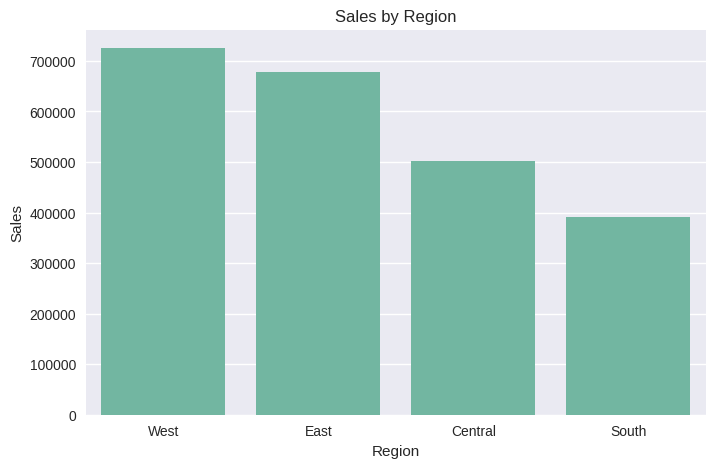

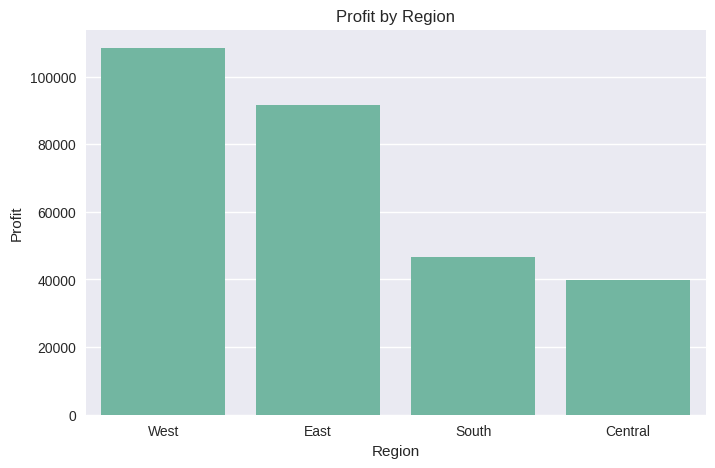

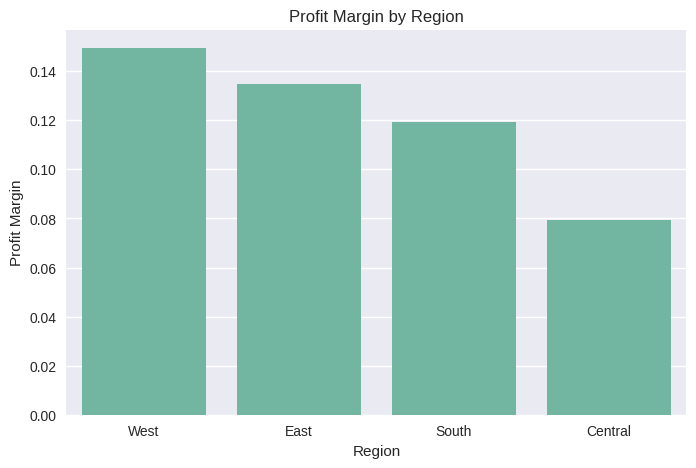

In [8]:
region = df.groupby("Region", as_index=False)[["Sales", "Profit"]].sum()
region["Profit_Margin"] = region["Profit"] / region["Sales"]

plt.figure(figsize=(8, 5))
sns.barplot(data=region.sort_values("Sales", ascending=False), x="Region", y="Sales")
plt.title("Sales by Region")
plt.ylabel("Sales")
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(data=region.sort_values("Profit", ascending=False), x="Region", y="Profit")
plt.title("Profit by Region")
plt.ylabel("Profit")
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(data=region.sort_values("Profit_Margin", ascending=False), x="Region", y="Profit_Margin")
plt.title("Profit Margin by Region")
plt.ylabel("Profit Margin")
plt.show()


### Discount vs. Profit Analysis
This cell visualizes the relationship between 'Discount' and 'Profit' using a scatter plot:
-   **Visualizes Discount vs. Profit:** A scatter plot is used to show individual data points, where each point represents a transaction's discount and corresponding profit. The `alpha=0.4` makes the points semi-transparent, helping to identify areas with high density of data.
-   **Highlights Break-even Point:** A horizontal red dashed line (`plt.axhline(0, color="red", linestyle="--", linewidth=1)`) is added at `Profit = 0`. This line serves as a visual reference to easily identify transactions that result in a loss (below the line) versus those that generate a profit (above the line), particularly in relation to the discount applied.

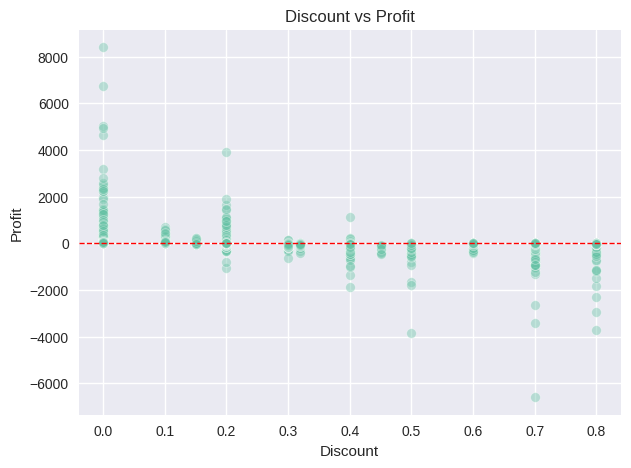

In [9]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="Discount", y="Profit", alpha=0.4)
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.show()


### Sales and Profit Analysis by Customer Segment
This cell analyzes sales and profit performance across different customer segments:
-   **Aggregates Data:** Groups the DataFrame by 'Segment' to calculate total 'Sales' and 'Profit'.
-   **Calculates Profit Margin:** Computes the 'Profit_Margin' for each segment by dividing 'Profit' by 'Sales'.
-   **Visualizes Sales by Segment:** Uses a bar plot to show total 'Sales' for each customer segment, identifying which segments contribute most to revenue.
-   **Visualizes Profit by Segment:** Displays a bar plot of total 'Profit' by segment, highlighting the most profitable customer groups.

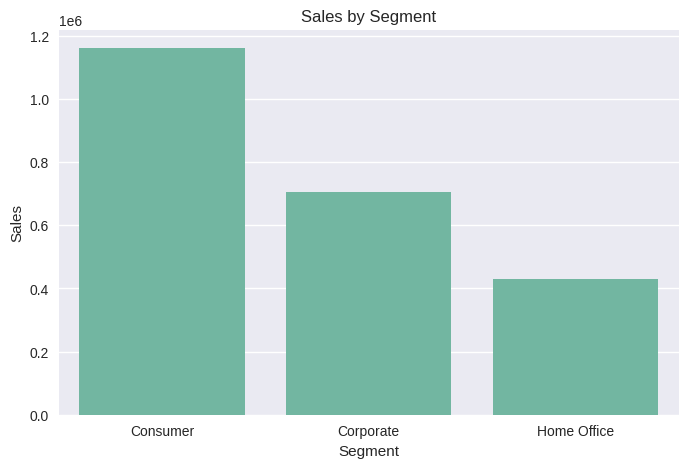

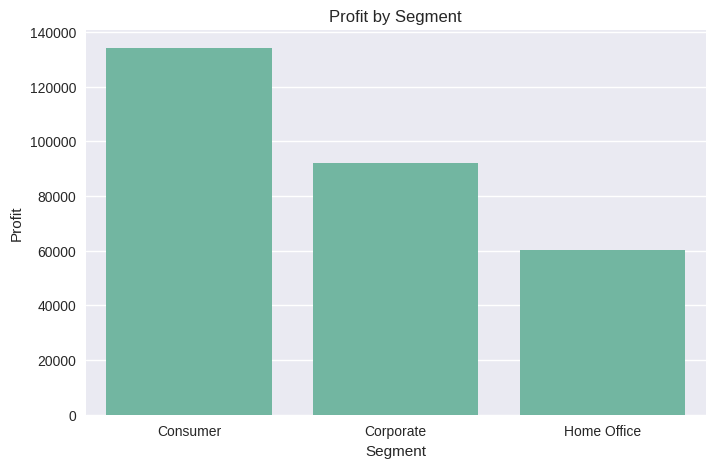

In [10]:
segment = df.groupby("Segment", as_index=False)[["Sales", "Profit"]].sum()
segment["Profit_Margin"] = segment["Profit"] / segment["Sales"]

plt.figure(figsize=(8, 5))
sns.barplot(data=segment, x="Segment", y="Sales")
plt.title("Sales by Segment")
plt.ylabel("Sales")
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(data=segment, x="Segment", y="Profit")
plt.title("Profit by Segment")
plt.ylabel("Profit")
plt.show()


### Profit Margin Analysis by Sub-Category
This cell calculates and visualizes the profit margin for each product sub-category:
-   **Calculates Profit Margin:** Computes the 'Profit_Margin' for each 'Sub-Category' by dividing its total 'Profit' by its total 'Sales'.
-   **Sorts Data:** Orders the sub-categories by their 'Profit_Margin' in descending order to easily identify the most and least profitable ones.
-   **Displays Table:** Prints a table showing 'Sub-Category', 'Sales', 'Profit', and 'Profit_Margin' for a detailed overview.
-   **Visualizes Profit Margin:** Uses a bar plot to visually represent the 'Profit_Margin' for each 'Sub-Category', making it easy to compare profitability. A horizontal red dashed line at 0 highlights sub-categories operating at a loss.

Profit Margins by Sub-Category:


,Sub-Category,Sales,Profit,Profit_Margin
10,Labels,12486.31,5546.25,0.44
12,Paper,78479.21,34053.57,0.43
7,Envelopes,16476.40,6964.18,0.42
6,Copiers,149528.03,55617.82,0.37
8,Fasteners,3024.28,949.52,0.31
0,Accessories,167380.32,41936.64,0.25
2,Art,27118.79,6527.79,0.24
1,Appliances,107532.16,18138.01,0.17
3,Binders,203412.73,30221.76,0.15
9,Furnishings,91705.16,13059.14,0.14


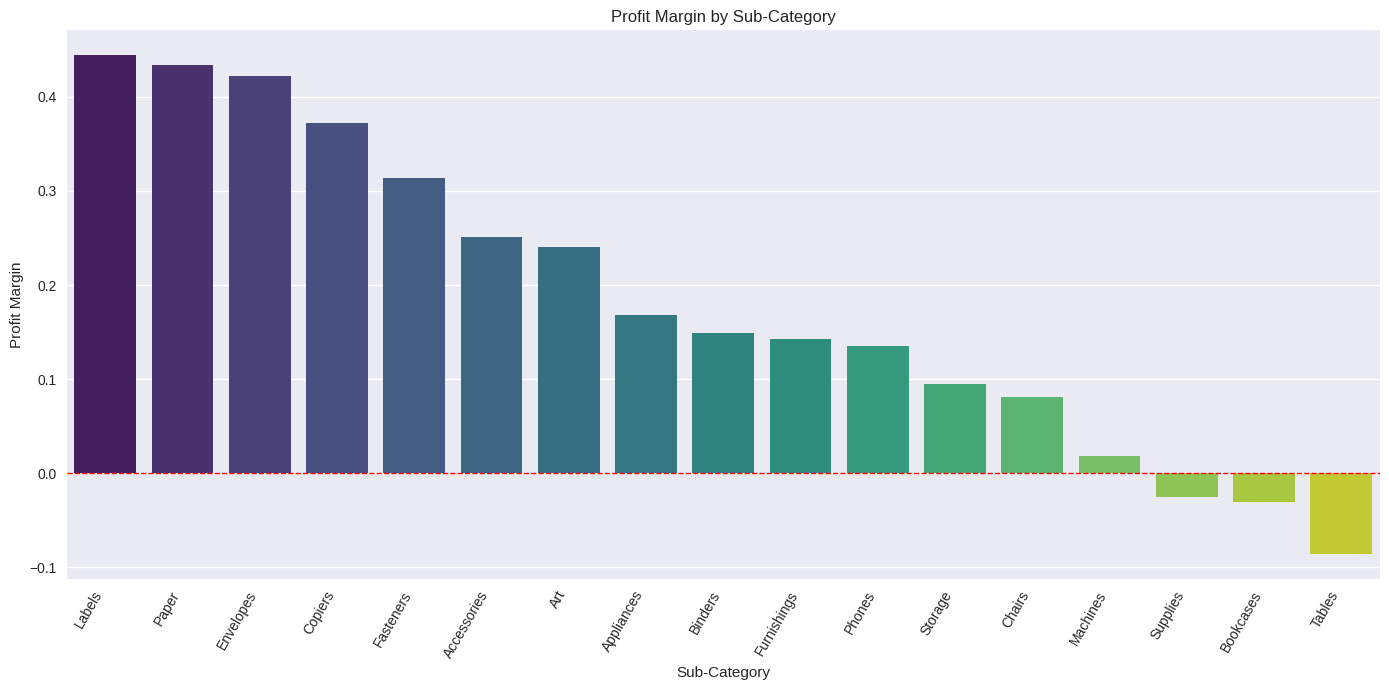

In [11]:
subcat["Profit_Margin"] = subcat["Profit"] / subcat["Sales"]
subcat_profit_margin = subcat.sort_values("Profit_Margin", ascending=False)

print("Profit Margins by Sub-Category:")
display(subcat_profit_margin[['Sub-Category', 'Sales', 'Profit', 'Profit_Margin']].round(2))

plt.figure(figsize=(14, 7))
sns.barplot(data=subcat_profit_margin, x="Sub-Category", y="Profit_Margin", hue="Sub-Category", palette="viridis", legend=False)
plt.title("Profit Margin by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Profit Margin")
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.show()

### Average Profit by Discount Range and Category Analysis
This cell investigates the relationship between discounts, profit, and product categories:
-   **Creates Discount Bins:** Defines numerical bins and corresponding labels to categorize the continuous 'Discount' column into discrete ranges (e.g., '0-10%', '10-20%').
-   **Calculates Average Profit:** Groups the DataFrame by 'Category' and the newly created 'Discount_Range' to compute the average 'Profit' for each combination.
-   **Visualizes Average Profit:** Uses a bar plot to display the average profit across different 'Discount_Range' for each 'Category'. The `hue='Category'` differentiates bars by product category, allowing for easy comparison. A horizontal red dashed line at 0 is added to visually indicate the break-even point, highlighting discount ranges where products start incurring losses.

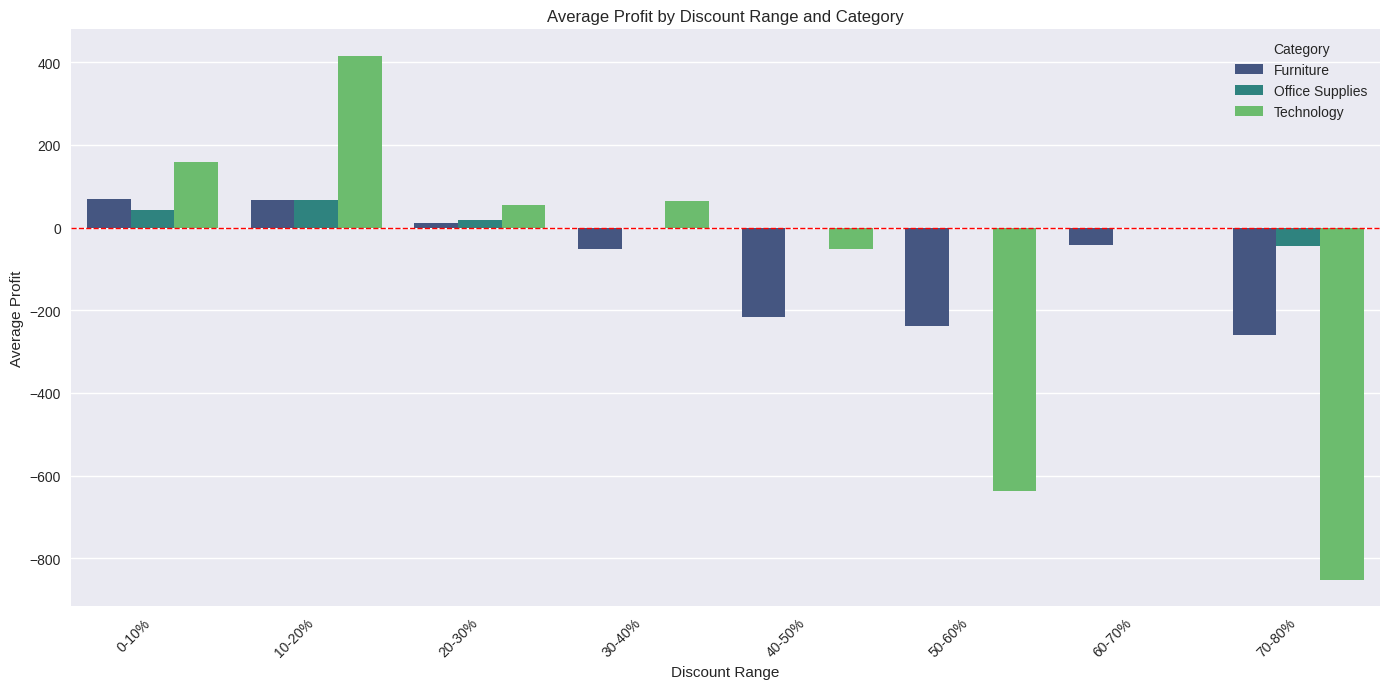

In [12]:
bins = [-0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
labels = ['0-10%', '10-20%', '20-30%', '30-40%', '40-50%', '50-60%', '60-70%', '70-80%']
df['Discount_Range'] = pd.cut(df['Discount'], bins=bins, labels=labels, right=False)

# Calculate average profit for each Category and Discount_Range
discount_profit_category = df.groupby(['Category', 'Discount_Range'], as_index=False, observed=False)['Profit'].mean()

plt.figure(figsize=(14, 7))
sns.barplot(data=discount_profit_category, x='Discount_Range', y='Profit', hue='Category', palette='viridis')
plt.title('Average Profit by Discount Range and Category')
plt.xlabel('Discount Range')
plt.ylabel('Average Profit')
plt.xticks(rotation=45, ha='right')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.legend(title='Category')
plt.tight_layout()
plt.show()

### Product-Level Performance Analysis
This cell performs a detailed analysis of product performance based on sales, profit, and quantity:
-   **Aggregates Data:** Groups the DataFrame by 'Product Name' to calculate the total 'Sales', 'Profit', and 'Quantity' for each product.
-   **Calculates Profit Margin:** Computes the 'Profit_Margin' for each product by dividing its total 'Profit' by its total 'Sales'.
-   **Displays Top 10 Products by Sales:** Shows the 10 products with the highest total sales, providing insight into best-selling items.
-   **Displays Top 10 Products by Profit:** Lists the 10 products that generate the most profit, highlighting the most financially successful items.
-   **Displays 10 Least Profitable Products:** Identifies the 10 products with the lowest profit (or highest losses), drawing attention to items that might need strategic review (e.g., pricing adjustments, discontinuation).

In [13]:
product_performance = df.groupby('Product Name', as_index=False)[['Sales', 'Profit', 'Quantity']].sum()
product_performance['Profit_Margin'] = product_performance['Profit'] / product_performance['Sales']

print("\n--- Top 10 Products by Sales ---")
display(product_performance.sort_values('Sales', ascending=False).head(10).round(2))

print("\n--- Top 10 Products by Profit ---")
display(product_performance.sort_values('Profit', ascending=False).head(10).round(2))

print("\n--- 10 Least Profitable Products ---")
display(product_performance.sort_values('Profit', ascending=True).head(10).round(2))



--- Top 10 Products by Sales ---


,Product Name,Sales,Profit,Quantity,Profit_Margin
404,Canon imageCLASS 2200 Advanced Copier,61599.82,25199.93,20,0.41
650,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.38,7753.04,31,0.28
444,Cisco TelePresence System EX90 Videoconferenci...,22638.48,-1811.08,6,-0.08
786,HON 5400 Series Task Chairs for Big and Tall,21870.58,0.00,39,0.00
686,GBC DocuBind TL300 Electric Binding System,19823.48,2233.51,37,0.11
688,GBC Ibimaster 500 Manual ProClick Binding System,19024.50,760.98,48,0.04
805,Hewlett Packard LaserJet 3310 Copier,18839.69,6983.88,38,0.37
787,HP Designjet T520 Inkjet Large Format Printer ...,18374.90,4094.98,12,0.22
683,GBC DocuBind P400 Electric Binding System,17965.07,-1878.17,27,-0.10
813,High Speed Automatic Electric Letter Opener,17030.31,-262.00,11,-0.02



--- Top 10 Products by Profit ---


,Product Name,Sales,Profit,Quantity,Profit_Margin
404,Canon imageCLASS 2200 Advanced Copier,61599.82,25199.93,20,0.41
650,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.38,7753.04,31,0.28
805,Hewlett Packard LaserJet 3310 Copier,18839.69,6983.88,38,0.37
400,Canon PC1060 Personal Laser Copier,11619.83,4570.93,19,0.39
787,HP Designjet T520 Inkjet Large Format Printer ...,18374.90,4094.98,12,0.22
165,Ativa V4110MDD Micro-Cut Shredder,7699.89,3772.95,11,0.49
19,"3D Systems Cube Printer, 2nd Generation, Magenta",14299.89,3717.97,11,0.26
1276,Plantronics Savi W720 Multi-Device Wireless He...,9367.29,3696.28,24,0.39
895,Ibico EPK-21 Electric Binding System,15875.92,3345.28,13,0.21
1840,Zebra ZM400 Thermal Label Printer,6965.70,3343.54,6,0.48



--- 10 Least Profitable Products ---


,Product Name,Sales,Profit,Quantity,Profit_Margin
475,Cubify CubeX 3D Printer Double Head Print,11099.96,-8879.97,9,-0.80
985,Lexmark MX611dhe Monochrome Laser Printer,16829.90,-4589.97,18,-0.27
476,Cubify CubeX 3D Printer Triple Head Print,7999.98,-3839.99,4,-0.48
425,Chromcraft Bull-Nose Wood Oval Conference Tabl...,9917.64,-2876.12,27,-0.29
376,Bush Advantage Collection Racetrack Conference...,9544.72,-1934.40,33,-0.20
683,GBC DocuBind P400 Electric Binding System,17965.07,-1878.17,27,-0.10
444,Cisco TelePresence System EX90 Videoconferenci...,22638.48,-1811.08,6,-0.08
1043,Martin Yale Chadless Opener Electric Letter Op...,16656.20,-1299.18,22,-0.08
285,Balt Solid Wood Round Tables,6518.75,-1201.06,19,-0.18
364,BoxOffice By Design Rectangular and Half-Moon ...,1706.25,-1148.44,15,-0.67


### Customer-Level Performance Analysis
This cell performs a detailed analysis of customer performance based on sales, profit, and quantity:
-   **Aggregates Data:** Groups the DataFrame by 'Customer ID' and 'Customer Name' to calculate the total 'Sales', 'Profit', and 'Quantity' for each customer.
-   **Calculates Profit Margin:** Computes the 'Profit_Margin' for each customer by dividing their total 'Profit' by their total 'Sales'.
-   **Displays Top 10 Customers by Sales:** Shows the 10 customers with the highest total sales, providing insight into the top revenue generators.
-   **Displays Top 10 Customers by Profit:** Lists the 10 customers who generate the most profit, highlighting the most financially valuable customers.
-   **Displays Customers with Negative Profit:** Identifies customers whose overall transactions have resulted in a net loss, drawing attention to relationships that might need strategic review (e.g., re-evaluating pricing, understanding their purchasing patterns).

In [14]:
customer_performance = df.groupby(['Customer ID', 'Customer Name'], as_index=False)[['Sales', 'Profit', 'Quantity']].sum()
customer_performance['Profit_Margin'] = customer_performance['Profit'] / customer_performance['Sales']

print("\n--- Top 10 Customers by Sales ---")
display(customer_performance.sort_values('Sales', ascending=False).head(10).round(2))

print("\n--- Top 10 Customers by Profit ---")
display(customer_performance.sort_values('Profit', ascending=False).head(10).round(2))

print("\n--- Customers with Negative Profit ---")
display(customer_performance[customer_performance['Profit'] < 0].sort_values('Profit', ascending=True).head(10).round(2))



--- Top 10 Customers by Sales ---


,Customer ID,Customer Name,Sales,Profit,Quantity,Profit_Margin
700,SM-20320,Sean Miller,25043.05,-1980.74,50,-0.08
741,TC-20980,Tamara Chand,19052.22,8981.32,42,0.47
621,RB-19360,Raymond Buch,15117.34,6976.10,71,0.46
730,TA-21385,Tom Ashbrook,14595.62,4703.79,36,0.32
6,AB-10105,Adrian Barton,14473.57,5444.81,73,0.38
434,KL-16645,Ken Lonsdale,14175.23,806.86,113,0.06
669,SC-20095,Sanjit Chand,14142.33,5757.41,87,0.41
327,HL-15040,Hunter Lopez,12873.30,5622.43,50,0.44
683,SE-20110,Sanjit Engle,12209.44,2650.68,78,0.22
131,CC-12370,Christopher Conant,12129.07,2177.05,34,0.18



--- Top 10 Customers by Profit ---


,Customer ID,Customer Name,Sales,Profit,Quantity,Profit_Margin
741,TC-20980,Tamara Chand,19052.22,8981.32,42,0.47
621,RB-19360,Raymond Buch,15117.34,6976.10,71,0.46
669,SC-20095,Sanjit Chand,14142.33,5757.41,87,0.41
327,HL-15040,Hunter Lopez,12873.30,5622.43,50,0.44
6,AB-10105,Adrian Barton,14473.57,5444.81,73,0.38
730,TA-21385,Tom Ashbrook,14595.62,4703.79,36,0.32
160,CM-12385,Christopher Martinez,8954.02,3899.89,34,0.44
424,KD-16495,Keith Dawkins,8181.26,3038.63,84,0.37
48,AR-10540,Andy Reiter,6608.45,2884.62,33,0.44
234,DR-12940,Daniel Raglin,8350.87,2869.08,57,0.34



--- Customers with Negative Profit ---


,Customer ID,Customer Name,Sales,Profit,Quantity,Profit_Margin
180,CS-12505,Cindy Stewart,5690.05,-6626.39,40,-1.16
310,GT-14635,Grant Thornton,9351.21,-4108.66,26,-0.44
459,LF-17185,Luke Foster,3930.51,-3583.98,69,-0.91
711,SR-20425,Sharelle Roach,3233.48,-3333.91,34,-1.03
322,HG-14965,Henry Goldwyn,3247.64,-2797.96,68,-0.86
555,NC-18415,Nathan Cano,2218.99,-2204.81,38,-0.99
666,SB-20290,Sean Braxton,8057.89,-2082.75,84,-0.26
700,SM-20320,Sean Miller,25043.05,-1980.74,50,-0.08
165,CP-12340,Christine Phan,5888.28,-1850.30,59,-0.31
560,NF-18385,Natalie Fritzler,8322.83,-1695.97,52,-0.20


### Prepare Data for Sales Forecasting
To perform sales forecasting, we need to ensure our aggregated monthly data is in a suitable time-series format. This cell will:
-   Combine 'Order_Year' and 'Order_Month' to create a new 'Date' column.
-   Convert the 'Date' column to a datetime object and set it as the DataFrame's index, which is essential for time-series analysis.
-   Sort the data by the new 'Date' index to ensure chronological order.

In [15]:
# Create a 'Date' column from Year and Month
monthly_sales_data = monthly.copy()
monthly_sales_data['Date'] = pd.to_datetime(monthly_sales_data['Order_Year'].astype(str) + '-' + monthly_sales_data['Order_Month'].astype(str) + '-01')

# Set 'Date' as the index for time series analysis
monthly_sales_data = monthly_sales_data.set_index('Date')

# Sort the data by date
monthly_sales_data = monthly_sales_data.sort_index()

# Display the prepared data
display(monthly_sales_data.head())

,Order_Year,Order_Month,Order_MonthName,Sales,Profit
Date,,,,,
2014-01-01,2014,1,Jan,14236.895,2450.1907
2014-02-01,2014,2,Feb,4519.892,862.3084
2014-03-01,2014,3,Mar,55691.009,498.7299
2014-04-01,2014,4,Apr,28013.973,3500.8940
2014-05-01,2014,5,May,23648.287,2738.7096


### Customer Segmentation (RFM Analysis)
To perform customer segmentation, we will use the RFM (Recency, Frequency, Monetary) model. This model analyzes customer behavior based on three key metrics:
-   **Recency:** How recently a customer has purchased.
-   **Frequency:** How often a customer purchases.
-   **Monetary:** How much a customer spends.

This cell will prepare the data for RFM calculation by determining the last purchase date, total orders, and total sales for each customer. It will also establish an 'Analysis Date' which is typically one day after the last transaction in the dataset.

In [16]:
# Calculate Recency: days since last purchase
analysis_date = df['Order Date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg(
    Recency=('Order Date', lambda date: (analysis_date - date.max()).days),
    Frequency=('Order ID', 'nunique'),
    Monetary=('Sales', 'sum')
).reset_index()

display(rfm.head())

,Customer ID,Recency,Frequency,Monetary
0,AA-10315,185,5,5563.560
1,AA-10375,20,9,1056.390
2,AA-10480,260,4,1790.512
3,AA-10645,56,6,5086.935
4,AB-10015,416,3,886.156


In [17]:
# Install mlxtend for frequent itemset mining and association rules
%pip install mlxtend

### Recommendation Systems: Top N Co-purchased Item Pairs
Since traditional association rule mining proved too memory-intensive for this dataset, this cell implements an alternative approach to identify co-purchased items:
-   **Generate Product Pairs:** For each order, all unique combinations of two products (pairs) are generated.
-   **Count Occurrences:** The frequency of each unique product pair across all orders is counted.
-   **Display Top N Pairs:** The most frequently occurring product pairs are displayed, providing direct insights into items that are often bought together.

In [18]:
from collections import defaultdict
from itertools import combinations

# Group products by order and get unique product names for each order
orders_products = df.groupby('Order ID')['Product Name'].apply(lambda x: list(set(x)))

# Dictionary to store co-occurrence counts of item pairs
co_occurrence_counts = defaultdict(int)

# Iterate through each order and generate all unique pairs of products
for products_in_order in orders_products:
    # Only consider orders with at least 2 unique products to form a pair
    if len(products_in_order) > 1:
        # Generate all unique combinations (pairs) of products in the order
        for item1, item2 in combinations(sorted(products_in_order), 2):
            # Ensure consistent order for pairs to count (e.g., A,B is same as B,A)
            co_occurrence_counts[(item1, item2)] += 1

# Convert to a DataFrame for easier sorting and display
co_occurrence_df = pd.DataFrame(
    list(co_occurrence_counts.items()),
    columns=['Item Pair', 'Co-occurrence Count']
)

# Sort by co-occurrence count in descending order
co_occurrence_df = co_occurrence_df.sort_values(by='Co-occurrence Count', ascending=False).reset_index(drop=True)

print("--- Top 20 Most Frequently Co-purchased Item Pairs ---")
display(co_occurrence_df.head(20))


--- Top 20 Most Frequently Co-purchased Item Pairs ---


,Item Pair,Co-occurrence Count
0,"(Newell 34, Staple envelope)",2
1,(Belkin Premiere Surge Master II 8-outlet surg...,2
2,"(Cisco SPA508G, Global Commerce Series High-Ba...",2
3,(Avery Recycled Flexi-View Covers for Binding ...,2
4,"(Staple envelope, Xerox 1971)",2
5,(Boston 16765 Mini Stand Up Battery Pencil Sha...,2
6,"(Acco Perma 4000 Stacking Storage Drawers, Can...",2
7,"(GBC VeloBinder Manual Binding System, Inserta...",2
8,(Anker Astro Mini 3000mAh Ultra-Compact Portab...,2
9,(Anker 36W 4-Port USB Wall Charger Travel Powe...,2


### Interactive Customer Demographics: Sales by Segment
This cell generates an interactive bar chart to visualize the total sales for each customer segment. Using `plotly.express`, this plot allows for interactive features such as zooming, panning, and displaying detailed information on hover.

In [18]:
import plotly.express as px

segment_sales = df.groupby('Segment', as_index=False)['Sales'].sum()

fig = px.bar(segment_sales,
             x='Segment',
             y='Sales',
             title='Interactive Sales by Customer Segment',
             labels={'Sales': 'Total Sales', 'Segment': 'Customer Segment'},
             hover_data={'Sales': ':.2f'})

fig.show()